<h1>Analysis of the First Pilot for "Easy Lessons"</h1>

In [568]:
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sqlite3

from util.survey_statements import MOTIVATIONAL_SURVEY_STATEMENTS 

# read in all three databases. 

In [569]:
TOWERS_DATA_PATH = "../../data/pilot-data/pilot-1/easy_lessons.db"
BASELINE_DATA_PATH = "../../data/pilot-data/pilot-1/hard_lessons.db"
VISUAL_SEARCH_DATA_PATH = "../../data/pilot-data/pilot-1/visual_search.db"

In [570]:
TRIAL_TABLE_NAME = "table_trial_log"
DEMOGRAPHICS_TABLE_NAME = "questionnaire_demographics"
MOTIVATIONAL_SURVEY_FIRST_ROUND_TABLE_NAME = "questionnaire_motivation_survey_first_round"
MOTIVATIONAL_SURVEY_TABLE_NAME = "questionnaire_motivation_survey"

In [571]:
FOLDER_NAME = "../../results/pilot-1/"

<h2>Read in Towers Data</h2>

In [572]:
towers_connection = sqlite3.connect(TOWERS_DATA_PATH)
cursor = towers_connection.cursor()

# reading all table names
table_list = [a for a in cursor.execute("SELECT name FROM sqlite_master WHERE type = 'table'")]

print("Your database contains the following tables:")
print(table_list)

Your database contains the following tables:
[('participant',), ('progress',), ('radio_grid_log',), ('display',), ('session_store',), ('questionnaire_motivation_survey',), ('questionnaire_prolific_start',), ('questionnaire_demographics',), ('questionnaire_motivation_survey_first_round',), ('table_trial_log',), ('table_responses',)]


In [573]:
TOWERS_TRIAL_DATA = pd.read_sql_query(f"SELECT *FROM {TRIAL_TABLE_NAME}", towers_connection)
TOWERS_DEMOGRAPHICS = pd.read_sql_query(f"SELECT * FROM {DEMOGRAPHICS_TABLE_NAME}", towers_connection)
TOWERS_SURVEY_ONE = pd.read_sql_query(f"SELECT * FROM {MOTIVATIONAL_SURVEY_FIRST_ROUND_TABLE_NAME}", towers_connection)
TOWERS_SURVEY = pd.read_sql_query(f"SELECT * FROM {MOTIVATIONAL_SURVEY_TABLE_NAME}", towers_connection)
towers_connection.close()

<h2>Read in Baseline Data </h2>

In [574]:
baseline_connection = sqlite3.connect(BASELINE_DATA_PATH)
cursor = baseline_connection.cursor()


BASELINE_TRIAL_DATA = pd.read_sql_query(f"SELECT *FROM {TRIAL_TABLE_NAME}", baseline_connection)
BASELINE_DEMOGRAPHICS = pd.read_sql_query(f"SELECT * FROM {DEMOGRAPHICS_TABLE_NAME}", baseline_connection)
BASELINE_SURVEY_ONE = pd.read_sql_query(f"SELECT * FROM {MOTIVATIONAL_SURVEY_FIRST_ROUND_TABLE_NAME}", baseline_connection)
BASELINE_SURVEY = pd.read_sql_query(f"SELECT * FROM {MOTIVATIONAL_SURVEY_TABLE_NAME}", baseline_connection)
baseline_connection.close()

<h2>Read in Visual Search Data</h2>

In [575]:
visual_search_connection = sqlite3.connect(VISUAL_SEARCH_DATA_PATH)
cursor = visual_search_connection.cursor()

VISUAL_SEARCH_TRIAL_DATA = pd.read_sql_query(f"SELECT *FROM {TRIAL_TABLE_NAME}", visual_search_connection)
VISUAL_SEARCH_DEMOGRAPHICS = pd.read_sql_query(f"SELECT * FROM {DEMOGRAPHICS_TABLE_NAME}", visual_search_connection)
VISUAL_SEARCH_SURVEY_ONE = pd.read_sql_query(f"SELECT * FROM {MOTIVATIONAL_SURVEY_FIRST_ROUND_TABLE_NAME}", visual_search_connection)
VISUAL_SEARCH_SURVEY = pd.read_sql_query(f"SELECT * FROM {MOTIVATIONAL_SURVEY_TABLE_NAME}", visual_search_connection)
visual_search_connection.close()

<h2>Removing Participants who Abandoned or didn't complete the Study</h2>

In [576]:
TOWER_IDS_TO_REMOVE = [1, 2, 3, 4,] 
BASELINE_IDS_TO_REMOVE = [1, 10, 12, 13, 15]
VISUAL_SEARCH_IDS_TO_REMOVE = [1, 12, 13]

In [577]:
TOWERS_TRIAL_DATA = TOWERS_TRIAL_DATA[~TOWERS_TRIAL_DATA["participantID"].isin(TOWER_IDS_TO_REMOVE)]
TOWERS_DEMOGRAPHICS = TOWERS_DEMOGRAPHICS[~TOWERS_DEMOGRAPHICS["participantID"].isin(TOWER_IDS_TO_REMOVE)]
TOWERS_SURVEY = TOWERS_SURVEY[~TOWERS_SURVEY["participantID"].isin(TOWER_IDS_TO_REMOVE)]
TOWERS_SURVEY_ONE = TOWERS_SURVEY_ONE[~TOWERS_SURVEY_ONE["participantID"].isin(TOWER_IDS_TO_REMOVE)]

BASELINE_TRIAL_DATA = BASELINE_TRIAL_DATA[~BASELINE_TRIAL_DATA["participantID"].isin(BASELINE_IDS_TO_REMOVE)]
BASELINE_DEMOGRAPHICS = BASELINE_DEMOGRAPHICS[~BASELINE_DEMOGRAPHICS["participantID"].isin(BASELINE_IDS_TO_REMOVE)]
BASELINE_SURVEY = BASELINE_SURVEY[~BASELINE_SURVEY["participantID"].isin(BASELINE_IDS_TO_REMOVE)]
BASELINE_SURVEY_ONE = BASELINE_SURVEY_ONE[~BASELINE_SURVEY_ONE["participantID"].isin(BASELINE_IDS_TO_REMOVE)]

VISUAL_SEARCH_TRIAL_DATA = VISUAL_SEARCH_TRIAL_DATA[~VISUAL_SEARCH_TRIAL_DATA["participantID"].isin(VISUAL_SEARCH_IDS_TO_REMOVE)]
VISUAL_SEARCH_DEMOGRAPHICS = VISUAL_SEARCH_DEMOGRAPHICS[~VISUAL_SEARCH_DEMOGRAPHICS["participantID"].isin(VISUAL_SEARCH_IDS_TO_REMOVE)]
VISUAL_SEARCH_SURVEY = VISUAL_SEARCH_SURVEY[~VISUAL_SEARCH_SURVEY["participantID"].isin(VISUAL_SEARCH_IDS_TO_REMOVE)]
VISUAL_SEARCH_SURVEY_ONE = VISUAL_SEARCH_SURVEY_ONE[~VISUAL_SEARCH_SURVEY_ONE["participantID"].isin(VISUAL_SEARCH_IDS_TO_REMOVE)]



<h2>Overview of Demographics</h2>

In [578]:
TOWERS_DEMOGRAPHICS['condition'] = 'towers'
BASELINE_DEMOGRAPHICS['condition'] = 'baseline'
VISUAL_SEARCH_DEMOGRAPHICS['condition'] = 'visual_search'

DEMOGRAPHICS = pd.concat([TOWERS_DEMOGRAPHICS, BASELINE_DEMOGRAPHICS, VISUAL_SEARCH_DEMOGRAPHICS], ignore_index=True)

In [579]:
DEMOGRAPHICS.columns

Index(['demographicsID', 'participantID', 'tag', 'timeStarted', 'timeEnded',
       'gender', 'genderText', 'age', 'occupation', 'compUsage',
       'videoGameUsage', 'input_device', 'input_device_description', 'CVD',
       'cvdType', 'visionAbility', 'visionAblilityType', 'condition'],
      dtype='str')

In [580]:
DEMOGRAPHICS['CVD'].value_counts()

CVD
No    30
Name: count, dtype: int64

In [581]:
DEMOGRAPHICS['visionAbility'].value_counts()

visionAbility
Yes    29
No      1
Name: count, dtype: int64

In [582]:
DEMOGRAPHICS['visionAblilityType'].value_counts()

visionAblilityType
    30
Name: count, dtype: int64

<p>There was one person who indicated they have a abnormal visual ability, but did not indicate in what way.</p>

In [583]:
DEMOGRAPHICS.groupby('condition')['gender'].value_counts()


condition      gender
baseline       Man       6
               Woman     4
towers         Woman     7
               Man       3
visual_search  Man       6
               Woman     4
Name: count, dtype: int64

In [584]:
DEMOGRAPHICS.groupby('condition')['input_device'].value_counts()

condition      input_device
baseline       Mouse           7
               Trackpad        3
towers         Trackpad        6
               Mouse           4
visual_search  Mouse           7
               Trackpad        3
Name: count, dtype: int64

<h2>Adherence</h2>

In [585]:
TOWERS_TRIAL_DATA['condition'] = 'towers'
VISUAL_SEARCH_TRIAL_DATA['condition'] = 'visual_search'
BASELINE_TRIAL_DATA['condition'] = 'baseline'

TRIAL_DATA = pd.concat([TOWERS_TRIAL_DATA, VISUAL_SEARCH_TRIAL_DATA, BASELINE_TRIAL_DATA], ignore_index=True)

# drop blocks where participants did not choose their condition 
TRIAL_DATA = TRIAL_DATA[~TRIAL_DATA["block"].isin([1, 2, 11])].copy()

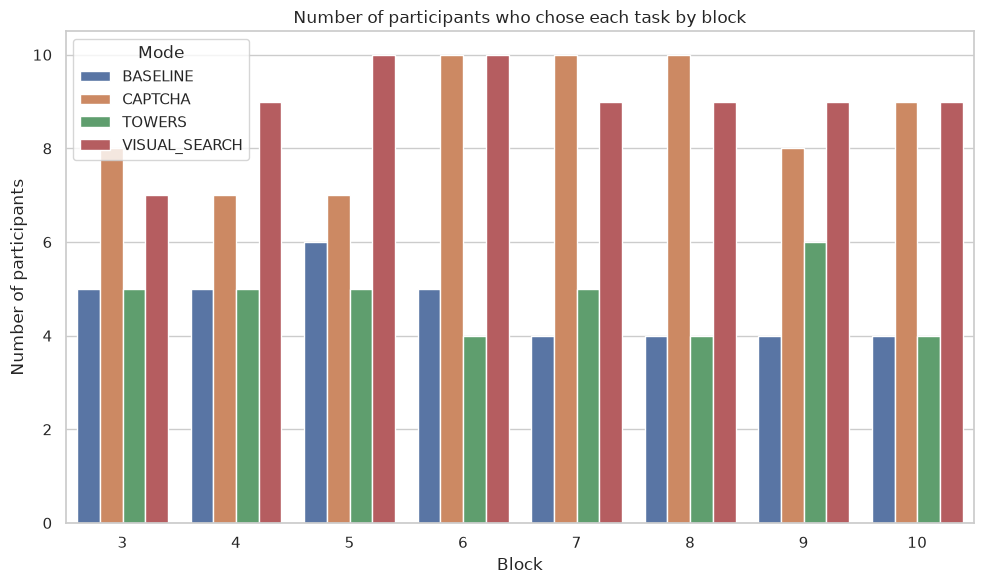

In [586]:
sns.set_theme(style="whitegrid")

participants_by_mode = (
    TRIAL_DATA
    .groupby(["block", "mode"])["participantID"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=participants_by_mode, x="block", y="count", hue="mode")

ax.set_xlabel("Block")
ax.set_ylabel("Number of participants")
ax.set_title("Number of participants who chose each task by block")
ax.legend(title="Mode")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

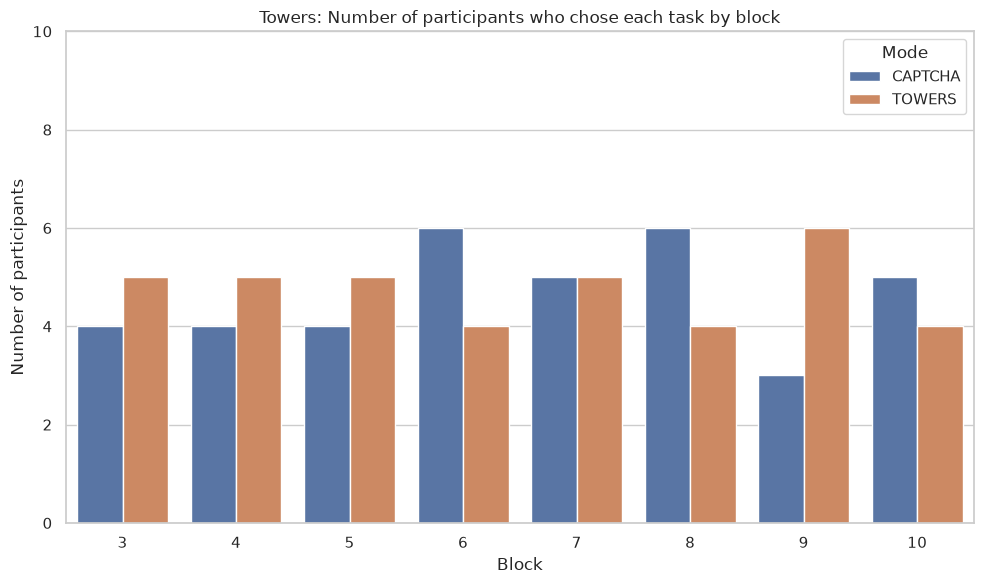

In [587]:
DATA = TOWERS_TRIAL_DATA[~TOWERS_TRIAL_DATA["block"].isin([1, 2, 11])].copy()

os.makedirs(f"./plots/{FOLDER_NAME}/adherence", exist_ok=True)

towers_participants_by_mode = (
    DATA
    .groupby(["block", "mode"])["participantID"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=towers_participants_by_mode, x="block", y="count", hue="mode")

ax.set_xlabel("Block")
ax.set_ylabel("Number of participants")
ax.set_title("Towers: Number of participants who chose each task by block")
ax.legend(title="Mode")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"./plots/{FOLDER_NAME}/adherence/towers-adherence.png",
        bbox_inches="tight",
)
plt.show()

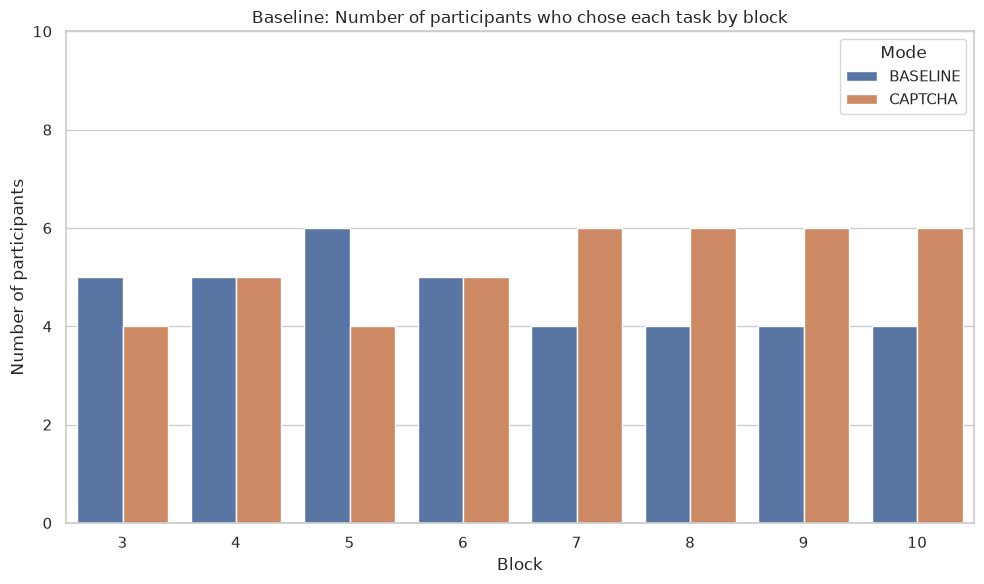

In [588]:
DATA = BASELINE_TRIAL_DATA[~BASELINE_TRIAL_DATA["block"].isin([1, 2, 11])].copy()

towers_participants_by_mode = (
    DATA
    .groupby(["block", "mode"])["participantID"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=towers_participants_by_mode, x="block", y="count", hue="mode")

ax.set_xlabel("Block")
ax.set_ylabel("Number of participants")
ax.set_title("Baseline: Number of participants who chose each task by block")
ax.legend(title="Mode")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"./plots/{FOLDER_NAME}/adherence/baseline-adherence.png",
        bbox_inches="tight",
)
plt.show()

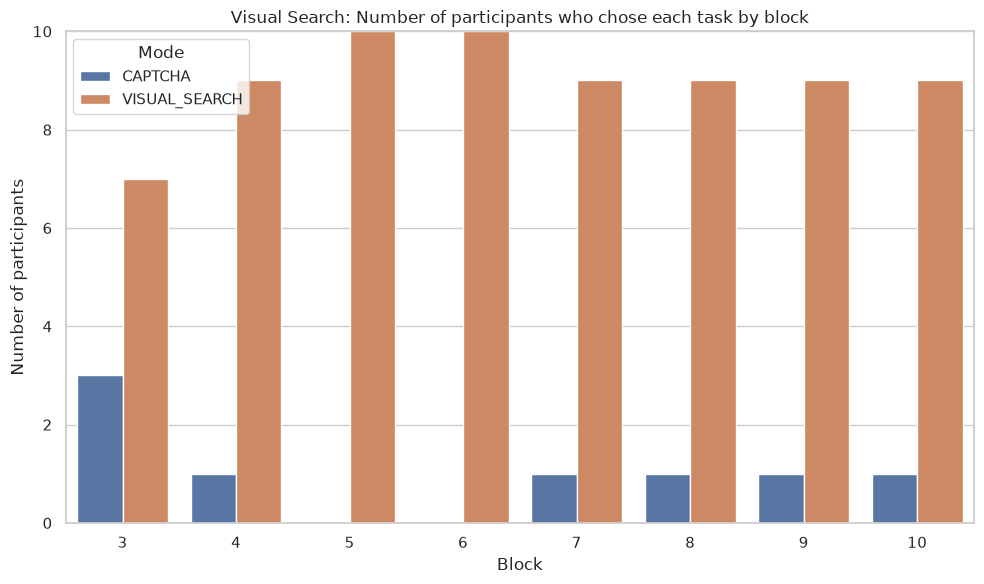

In [589]:
DATA = VISUAL_SEARCH_TRIAL_DATA[~VISUAL_SEARCH_TRIAL_DATA["block"].isin([1, 2, 11])].copy()

towers_participants_by_mode = (
    DATA
    .groupby(["block", "mode"])["participantID"]
    .nunique()
    .reset_index(name="count")
)

plt.figure(figsize=(10, 6))
ax = sns.barplot(data=towers_participants_by_mode, x="block", y="count", hue="mode")

ax.set_xlabel("Block")
ax.set_ylabel("Number of participants")
ax.set_title("Visual Search: Number of participants who chose each task by block")
ax.legend(title="Mode")
plt.ylim(0, 10)
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"./plots/{FOLDER_NAME}/adherence/visual-search-adherence.png",
        bbox_inches="tight",
)
plt.show()

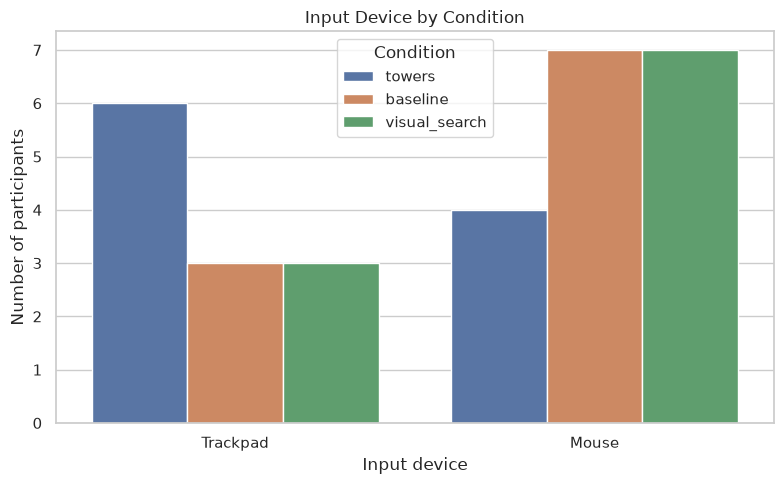

In [616]:
demographics_plot_dir = f"./plots/{FOLDER_NAME}/demographics"
os.makedirs(demographics_plot_dir, exist_ok=True)

device_data = DEMOGRAPHICS.drop_duplicates(
    subset=["participantID", "condition"]
)

plt.figure(figsize=(8, 5))
ax = sns.countplot(
    data=device_data,
    x="input_device",
    hue="condition",
    hue_order=condition_order,
    order=["Trackpad", "Mouse"],
)

ax.set_xlabel("Input device")
ax.set_ylabel("Number of participants")
ax.set_title("Input Device by Condition")
ax.legend(title="Condition")
plt.tight_layout()
plt.savefig(
    f"{demographics_plot_dir}/input_device_by_condition.png",
    bbox_inches="tight",
)
plt.show()

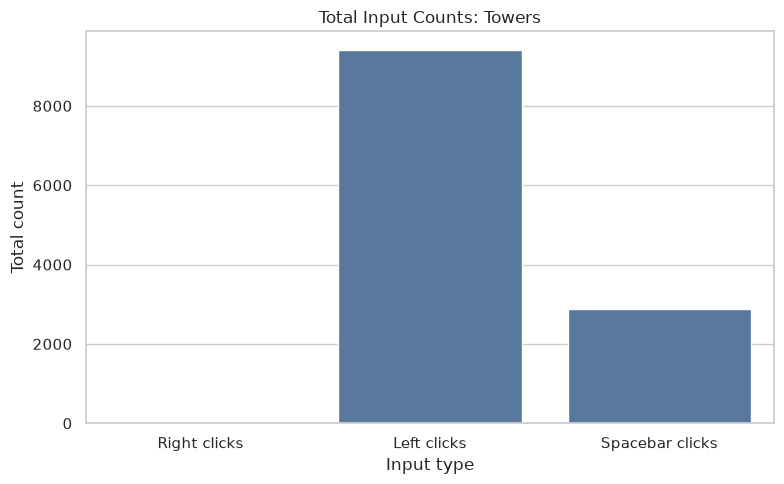

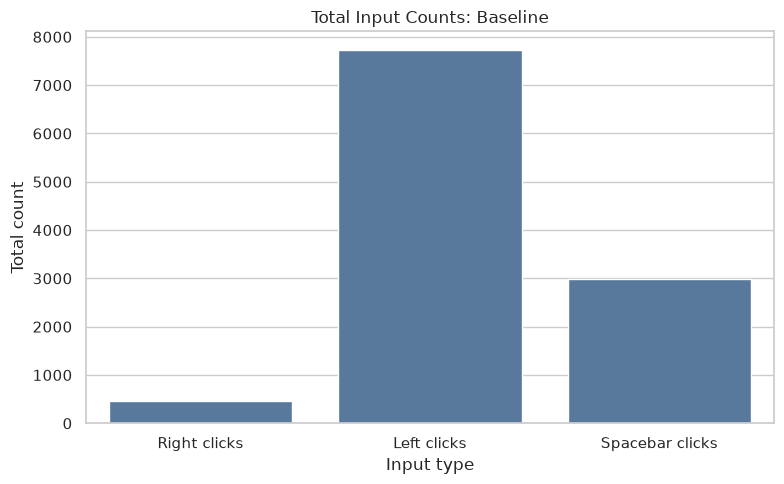

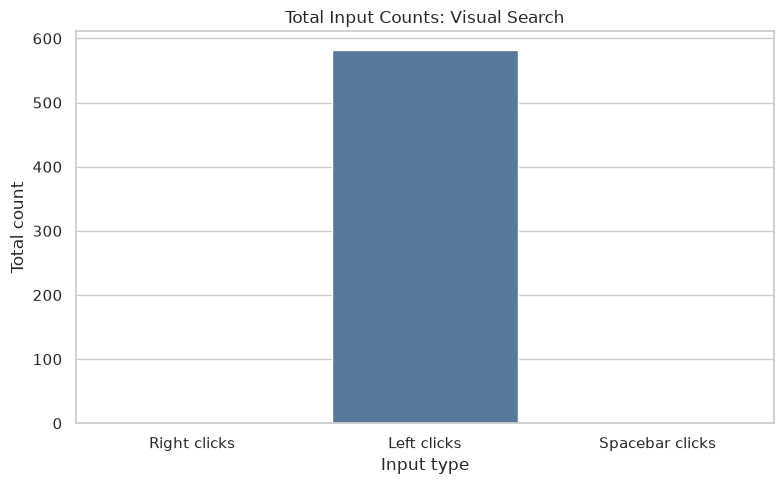

In [615]:
click_columns = [
    "numRightClicks",
    "numLeftClicks",
    "numSpaceBarClicks",
]

click_plot_dir = f"./plots/{FOLDER_NAME}/click_counts"
os.makedirs(click_plot_dir, exist_ok=True)

for condition in condition_order:
    condition_data = TRIAL_DATA[
        (TRIAL_DATA["condition"] == condition)
        & (TRIAL_DATA["mode"] != "CAPTCHA")
    ]

    click_totals = condition_data[click_columns].sum().reset_index()
    click_totals.columns = ["click_type", "count"]

    plt.figure(figsize=(8, 5))
    ax = sns.barplot(
        data=click_totals,
        x="click_type",
        y="count",
        color="#4C78A8",
    )

    ax.set_xlabel("Input type")
    ax.set_ylabel("Total count")
    ax.set_title(f"Total Input Counts: {condition.replace('_', ' ').title()}")
    plt.xticks(
        range(3),
        ["Right clicks", "Left clicks", "Spacebar clicks"],
    )
    plt.tight_layout()
    plt.savefig(
        f"{click_plot_dir}/{condition}_click_counts.png",
        bbox_inches="tight",
    )
    plt.show()

<h2>Memory Test Data</h2>

In [590]:
TEST_DATA = pd.concat([TOWERS_TRIAL_DATA, BASELINE_TRIAL_DATA, VISUAL_SEARCH_TRIAL_DATA], ignore_index=True)
TEST_DATA = TEST_DATA[TEST_DATA['block'] == 11]

/tmp/ipykernel_67943/2544677509.py:6: FutureWarning: 

The `ci` parameter is deprecated. Use `errorbar=('ci', 95)` for the same effect.

  ax = sns.barplot(
/tmp/ipykernel_67943/2544677509.py:6: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  ax = sns.barplot(


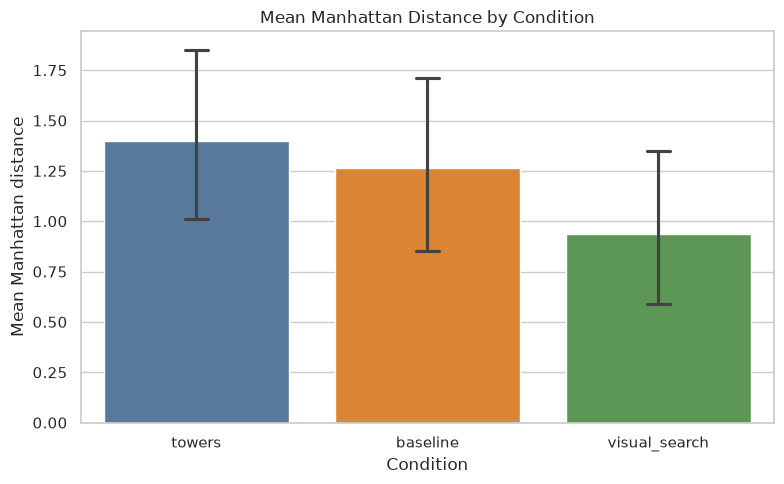

In [591]:
condition_order = ["towers", "baseline", "visual_search"]

os.makedirs(f"./plots/{FOLDER_NAME}/memory-test/", exist_ok=True)

plt.figure(figsize=(8, 5))
ax = sns.barplot(
    data=TEST_DATA,
    x="condition",
    y="manhattan",
    order=condition_order,
    errorbar="sd",
    ci=95,
    capsize=0.1,
    palette=["#4C78A8", "#F58518", "#54A24B"],
)

ax.set_xlabel("Condition")
ax.set_ylabel("Mean Manhattan distance")
ax.set_title("Mean Manhattan Distance by Condition")
plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig(
    f"./plots/{FOLDER_NAME}/memory-test/memory-test-summary.png",
        bbox_inches="tight",
)
plt.show()

<h2>Survey Data</h2>

In [592]:
def format_likert_data_for_histogram(df: pd.DataFrame, likert_columns: list) -> pd.DataFrame:
    for column_name in likert_columns:
        df[column_name] = df[column_name].replace('1 (Strongly Disagree)', '1')
        df[column_name] = df[column_name].replace('7 (Strongly Agree)', '7')
        df[column_name] = df[column_name].replace('4 (Neutral)', '4')
        df[column_name] = df[column_name].astype('int64')
    return df

In [593]:
TOWERS_SURVEY['mode'] = 'Towers'
BASELINE_SURVEY['mode'] = 'Baseline'
VISUAL_SEARCH_SURVEY['mode'] = 'Visual Search'

In [594]:
TOWERS_SURVEY['tag'] = TOWERS_SURVEY['tag'].astype(int)
BASELINE_SURVEY['tag'] = BASELINE_SURVEY['tag'].astype(int)
VISUAL_SEARCH_SURVEY['tag'] = VISUAL_SEARCH_SURVEY['tag'].astype(int)

In [595]:
#FIXME: we need to track this better in the experiment, and set it here where it can't be inaccurate
# their response here should only affect the next round
def assign_captcha_to_next_block(survey):
    captcha_responses = survey[
        survey["adherence"] == "I would prefer to do 10 Captchas."
    ][["participantID", "tag"]].copy()

    captcha_responses["tag"] = pd.to_numeric(captcha_responses["tag"]) + 1

    next_block = survey.merge(
        captcha_responses.assign(_captcha_next=True),
        on=["participantID", "tag"],
        how="left",
    )["_captcha_next"].fillna(False)

    survey.loc[next_block, "mode"] = "CAPTCHA"


for survey in (
    TOWERS_SURVEY,
    BASELINE_SURVEY,
    VISUAL_SEARCH_SURVEY,
):
    assign_captcha_to_next_block(survey)
    

In [596]:
TOWERS_SURVEY['adherence']

0     I would continue virtual keyboard training.
1               I would prefer to do 10 Captchas.
2     I would continue virtual keyboard training.
3               I would prefer to do 10 Captchas.
4               I would prefer to do 10 Captchas.
                         ...                     
77    I would continue virtual keyboard training.
78    I would continue virtual keyboard training.
79    I would continue virtual keyboard training.
80    I would continue virtual keyboard training.
81    I would continue virtual keyboard training.
Name: adherence, Length: 82, dtype: str

In [597]:
CAPTCHA_ONLY_SURVEY = pd.concat([TOWERS_SURVEY_ONE, BASELINE_SURVEY_ONE, VISUAL_SEARCH_SURVEY_ONE])
CAPTCHA_ONLY_SURVEY['mode'] = 'CAPTCHA'
SURVEY_DATA = pd.concat([TOWERS_SURVEY, BASELINE_SURVEY, VISUAL_SEARCH_SURVEY])

CAPTCHA_ONLY_SURVEY['block'] = 1
SURVEY_DATA['block'] = SURVEY_DATA['tag'].astype(int)+1

ALL_SURVEY_DATA = pd.concat([CAPTCHA_ONLY_SURVEY, SURVEY_DATA])

ALL_SURVEY_DATA = format_likert_data_for_histogram(ALL_SURVEY_DATA, MOTIVATIONAL_SURVEY_STATEMENTS)

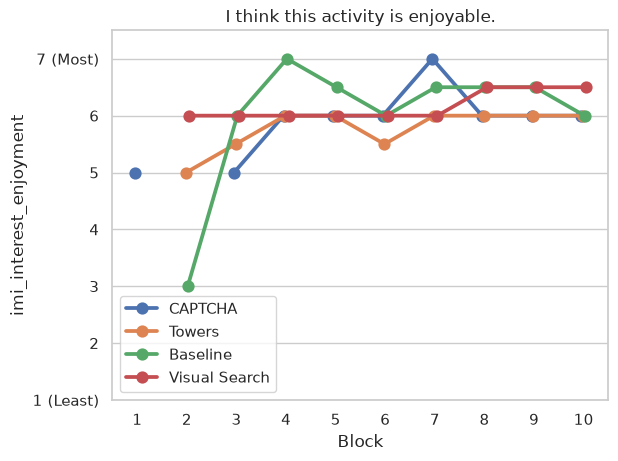

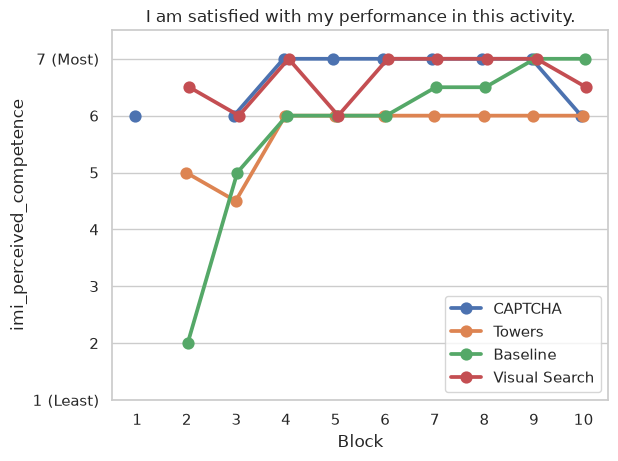

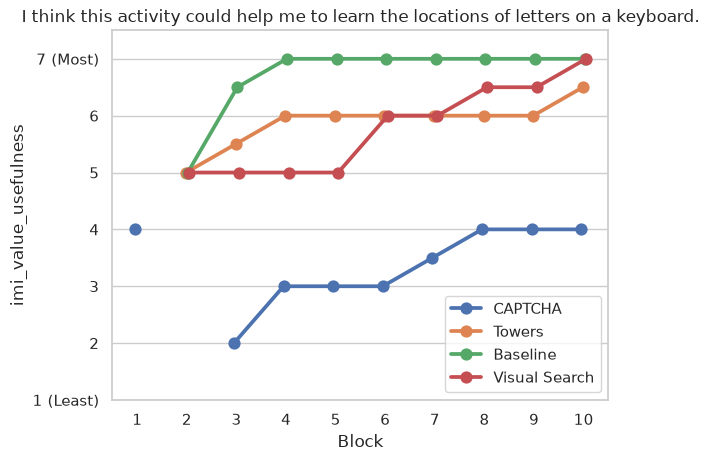

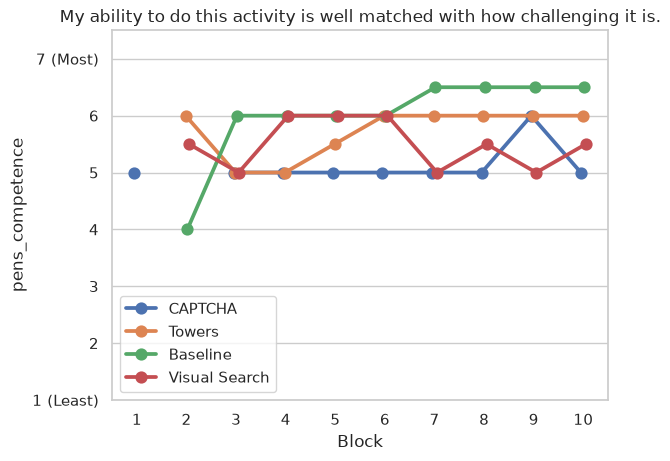

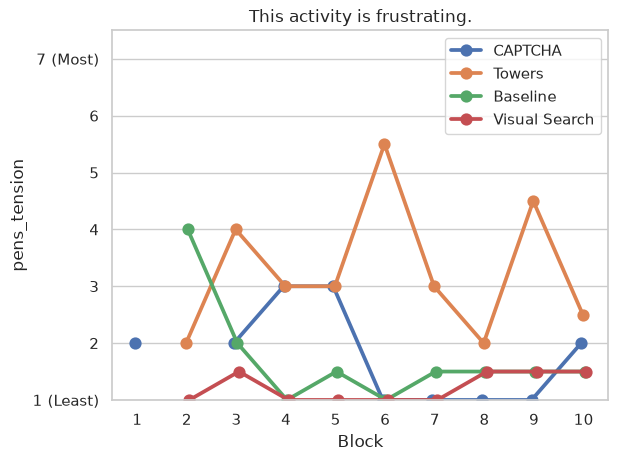

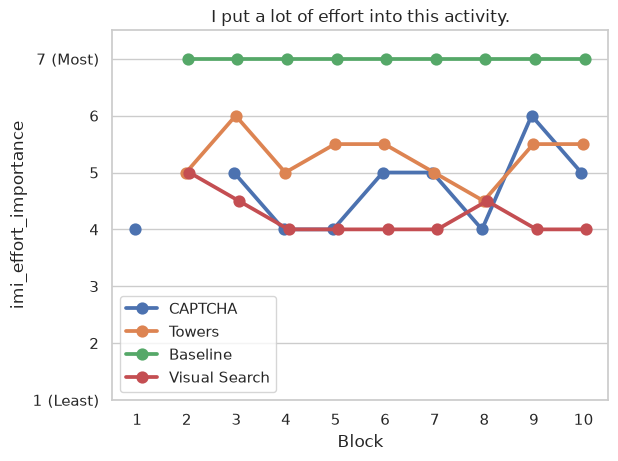

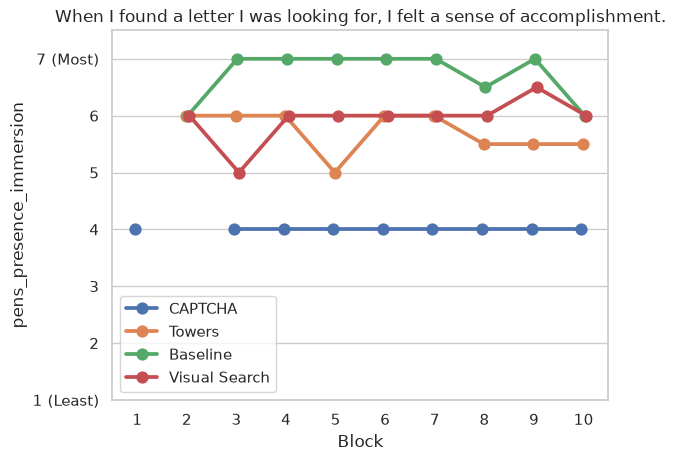

In [598]:
# all the survey plots like before

if not os.path.exists(f"./plots/{FOLDER_NAME}/surveys_pointplots_medians/"):
    os.makedirs(f"./plots/{FOLDER_NAME}/surveys_pointplots_medians/")

for statement in MOTIVATIONAL_SURVEY_STATEMENTS:
    plt.figure()
    plt.ylim(1, 7.5)

    sns.pointplot(
        data=ALL_SURVEY_DATA,
        x="block",
        y=statement,
        hue="mode",
        estimator=pd.Series.median,
        errorbar=None,
        dodge=True,
    )

    plt.yticks(
        [1, 2, 3, 4, 5, 6, 7],
        ["1 (Least)", "2", "3", "4", "5", "6", "7 (Most)"],
    )
    plt.title(MOTIVATIONAL_SURVEY_STATEMENTS[statement])
    plt.xlabel("Block")
    plt.legend(title="")
    plt.savefig(
        f"./plots/{FOLDER_NAME}/surveys_pointplots_medians/{statement}.png",
        bbox_inches="tight",
    )
    plt.show()

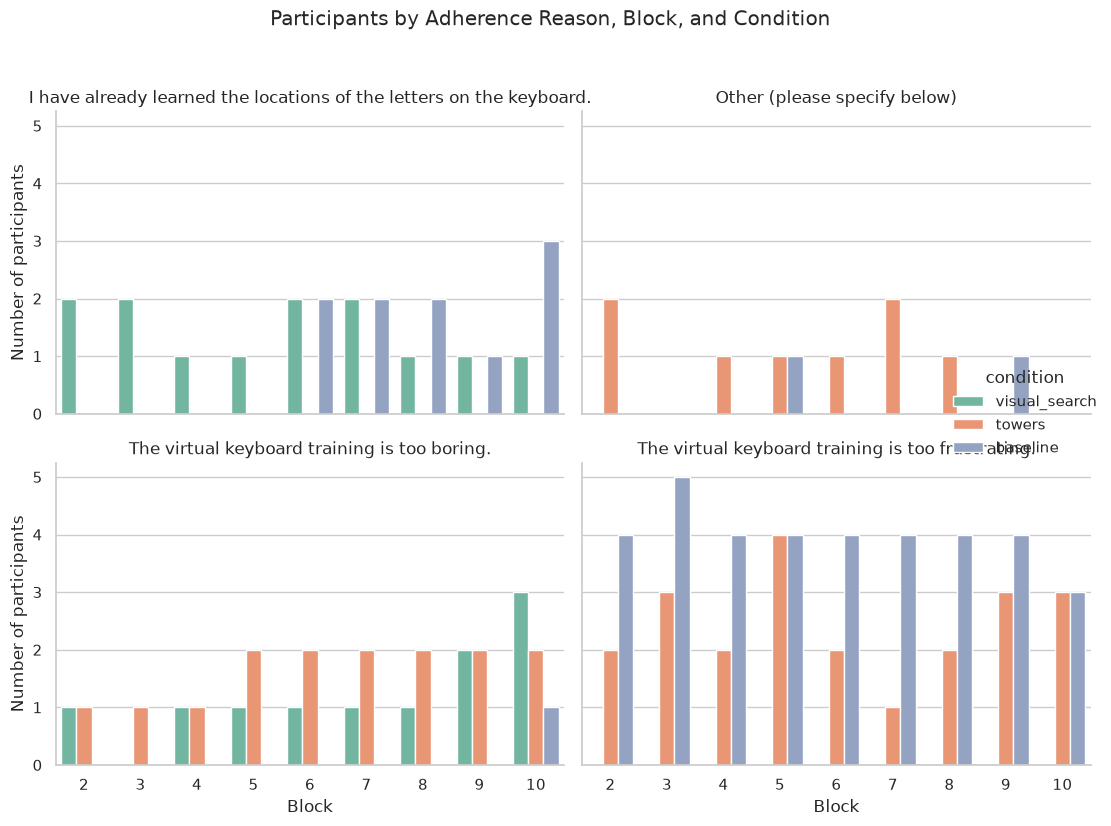

In [599]:
survey_by_condition = pd.concat(
    [
        TOWERS_SURVEY.assign(condition="towers"),
        BASELINE_SURVEY.assign(condition="baseline"),
        VISUAL_SEARCH_SURVEY.assign(condition="visual_search"),
    ],
    ignore_index=True,
).copy()

survey_by_condition["block"] = pd.to_numeric(survey_by_condition["tag"]) + 1
survey_by_condition["adherence_reason"] = (
    survey_by_condition["adherence_reason"]
    .replace("", pd.NA)
    .dropna()
)

participant_adherence_counts = (
    survey_by_condition
    .groupby(["block", "adherence_reason", "condition"])["participantID"]
    .nunique()
    .reset_index(name="participants")
)

g = sns.catplot(
    data=participant_adherence_counts,
    x="block",
    y="participants",
    hue="condition",
    col="adherence_reason",
    kind="bar",
    col_wrap=2,
    height=4,
    aspect=1.2,
    palette="Set2",
)

g.set_axis_labels("Block", "Number of participants")
g.set_titles("{col_name}")
g.figure.suptitle("Participants by Adherence Reason, Block, and Condition", y=1.03)
plt.tight_layout()
plt.show()

In [600]:
survey_by_condition.columns

Index(['motivation_surveyID', 'participantID', 'tag', 'timeStarted',
       'timeEnded', 'imi_interest_enjoyment', 'imi_perceived_competence',
       'imi_value_usefulness', 'pens_competence', 'attention', 'pens_tension',
       'imi_effort_importance', 'pens_presence_immersion', 'adherence',
       'adherence_reason', 'adherence_reason_text', 'mode', 'condition',
       'block'],
      dtype='str')

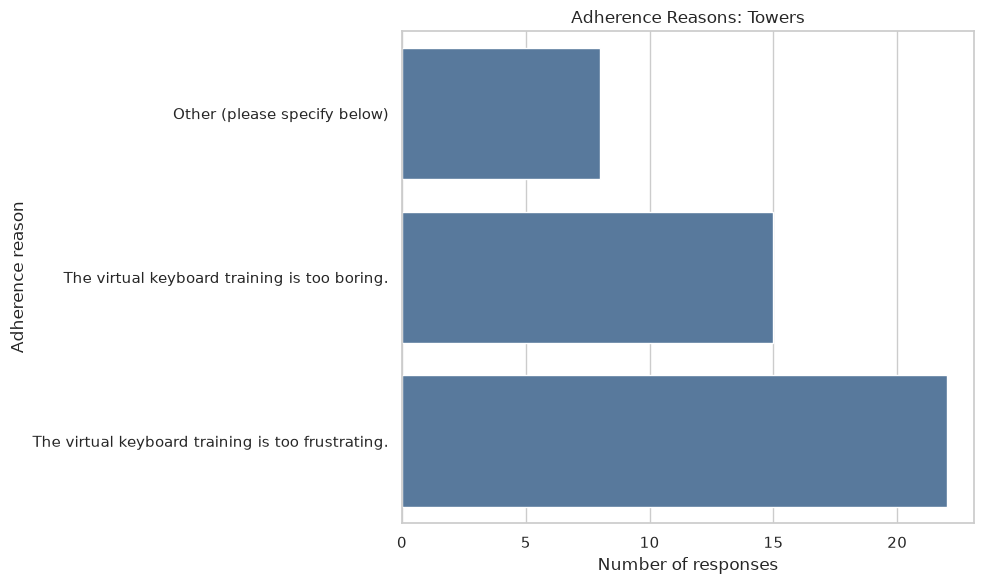

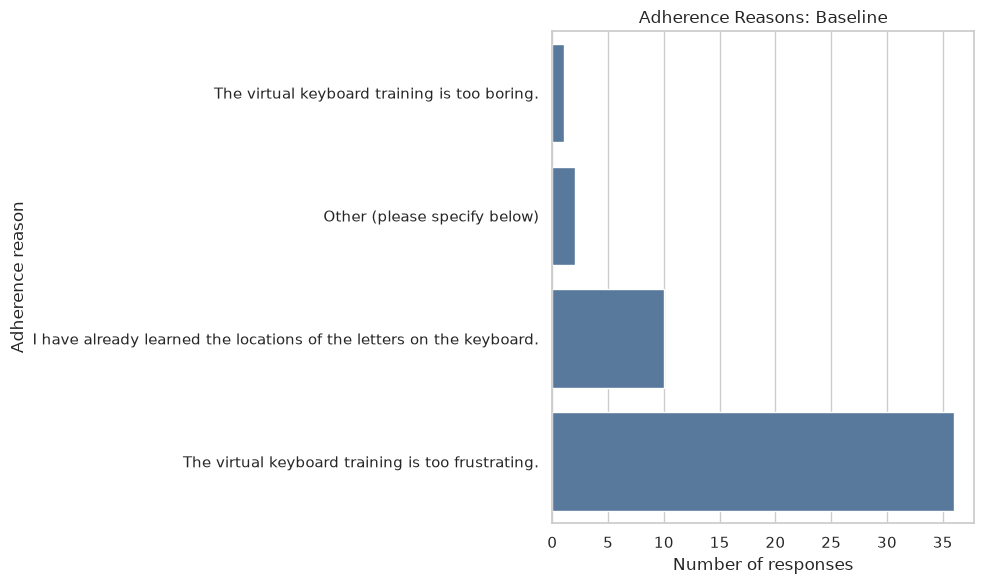

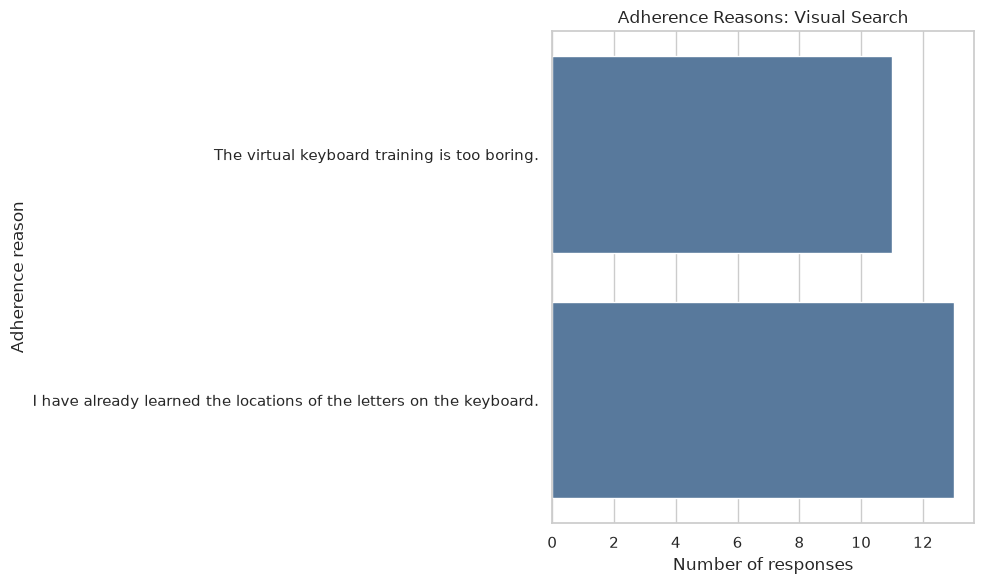

In [601]:
adherence_plot_dir = f"./plots/{FOLDER_NAME}/surveys_adherence_reason"
os.makedirs(adherence_plot_dir, exist_ok=True)

for condition in condition_order:
    condition_data = survey_by_condition[
        survey_by_condition["condition"] == condition
    ].copy()

    reason_counts = (
        condition_data["adherence_reason"]
        .dropna()
        .value_counts()
        .sort_values()
    )

    plt.figure(figsize=(10, 6))
    ax = sns.barplot(
        x=reason_counts.values,
        y=reason_counts.index,
        color="#4C78A8",
    )

    ax.set_xlabel("Number of responses")
    ax.set_ylabel("Adherence reason")
    ax.set_title(f"Adherence Reasons: {condition.replace('_', ' ').title()}")
    plt.tight_layout()

    plt.savefig(
        f"{adherence_plot_dir}/adherence_reasons_{condition}.png",
        bbox_inches="tight",
    )
    plt.show()

In [ ]:
# did they use the spacebar at all? How many on trackpad?

In [613]:
# other reasons: 

survey_by_condition[["condition", "adherence_reason_text"]].value_counts()

condition      adherence_reason_text                                                                                                        
visual_search                                                                                                                                   89
baseline                                                                                                                                        87
towers                                                                                                                                          74
               Easier                                                                                                                            4
baseline       take a break                                                                                                                      2
towers         I don't see how the virtual keyboard training would help me learn the position of the position of the letters

<h2>Experiment Data Analyzed with Demographics</h2>

<h3>Gender</h3>

In [602]:
TEST_DATA["unique_id"] = TEST_DATA["participantID"].astype(str) + "_" + TEST_DATA["condition"].astype(str)
DEMOGRAPHICS["unique_id"] = DEMOGRAPHICS["participantID"].astype(str) + "_" + DEMOGRAPHICS["condition"].astype(str)

In [603]:
MEMORY_TEST_WITH_DEMOGRAPHICS = pd.merge(
    TEST_DATA,
    DEMOGRAPHICS,
    left_on=['unique_id'],
    right_on=['unique_id'],
    how='inner',
    suffixes=('_test', '_demographics')
)

In [604]:
MEMORY_TEST_WITH_DEMOGRAPHICS.columns

Index(['trial_logID', 'participantID_test', 'timeSubmitted', 'prolificID',
       'mode', 'block', 'trial', 'currentTargets', 'targetSelectionOrder',
       'trialTime', 'timeToFirstClick', 'errors', 'score', 'numLeftClicks',
       'numRightClicks', 'numSpaceBarClicks', 'targetX', 'targetY', 'clickX',
       'clickY', 'lettersClicked', 'manhattan', 'euclidean', 'confidence',
       'condition_test', 'unique_id', 'demographicsID',
       'participantID_demographics', 'tag', 'timeStarted', 'timeEnded',
       'gender', 'genderText', 'age', 'occupation', 'compUsage',
       'videoGameUsage', 'input_device', 'input_device_description', 'CVD',
       'cvdType', 'visionAbility', 'visionAblilityType',
       'condition_demographics'],
      dtype='str')

In [605]:
MEMORY_TEST_WITH_DEMOGRAPHICS['condition_demographics'].value_counts()

condition_demographics
towers           80
baseline         80
visual_search    80
Name: count, dtype: int64

In [606]:
MEMORY_TEST_WITH_DEMOGRAPHICS['condition_test'].value_counts()

condition_test
towers           80
baseline         80
visual_search    80
Name: count, dtype: int64

/tmp/ipykernel_67943/2447203706.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")
/tmp/ipykernel_67943/2447203706.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")
/tmp/ipykernel_67943/2447203706.py:9: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")


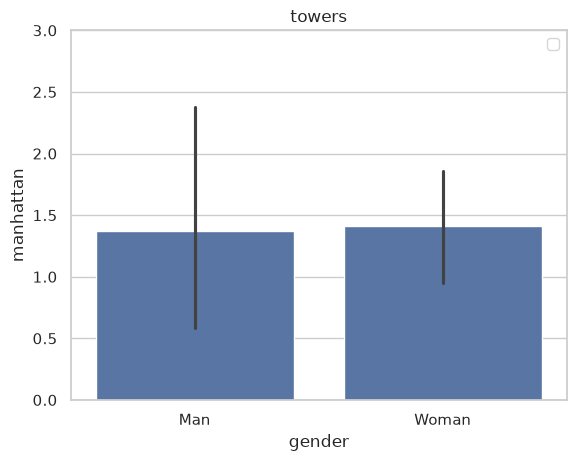

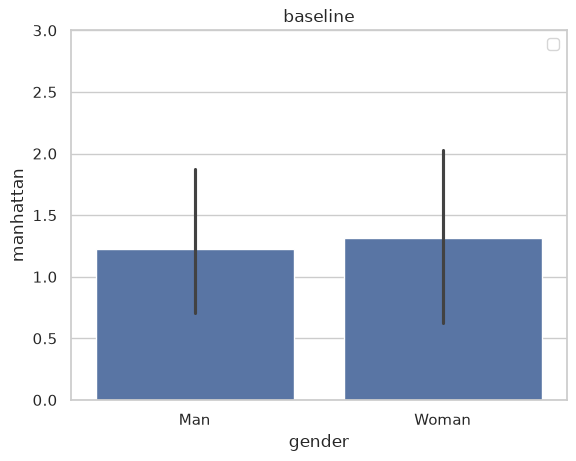

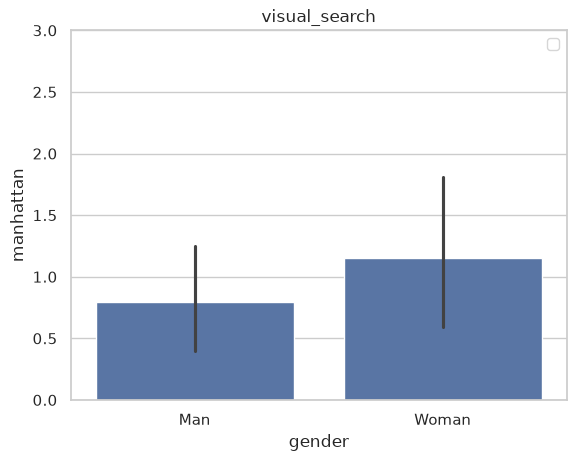

In [607]:
conditions = MEMORY_TEST_WITH_DEMOGRAPHICS['condition_demographics'].unique()

for condition in conditions:
    data= MEMORY_TEST_WITH_DEMOGRAPHICS[MEMORY_TEST_WITH_DEMOGRAPHICS['condition_demographics']==condition]
    plt.figure()
    sns.barplot(data=data, x="gender", y="manhattan")
    plt.title(f"{condition}")
    plt.ylim(0,3)
    plt.legend(title="")
    plt.savefig(f"./plots/{FOLDER_NAME}/memory-test/memory_test_by_gender_{condition}.png")

<h3>Gamers</h3>

In [608]:

MEMORY_TEST_WITH_DEMOGRAPHICS[['videoGameUsage', 'unique_id']].drop_duplicates().to_csv("video_game_data.csv", index=False)

In [609]:
def _assignVideoGameUseBucket(x):
    if x>= 15:
        return "High"
    elif x >= 4:
        return "Medium"
    else:
        return "Low"

In [610]:
# gamer breakdown
MEMORY_TEST_WITH_DEMOGRAPHICS['gaming_bucket'] = MEMORY_TEST_WITH_DEMOGRAPHICS['videoGameUsage'].apply(lambda x: _assignVideoGameUseBucket(x))

/tmp/ipykernel_67943/1429443393.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")
/tmp/ipykernel_67943/1429443393.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")
/tmp/ipykernel_67943/1429443393.py:11: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  plt.legend(title="")


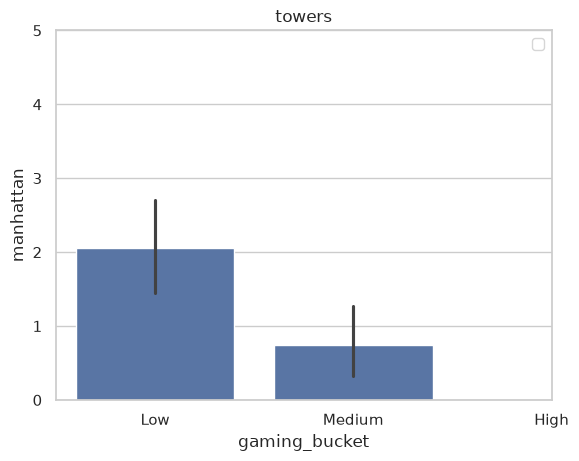

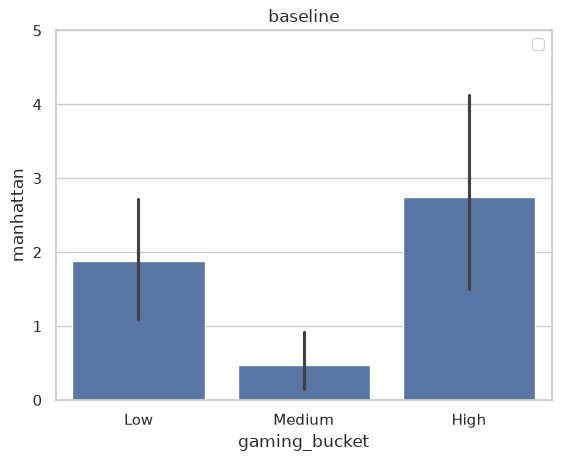

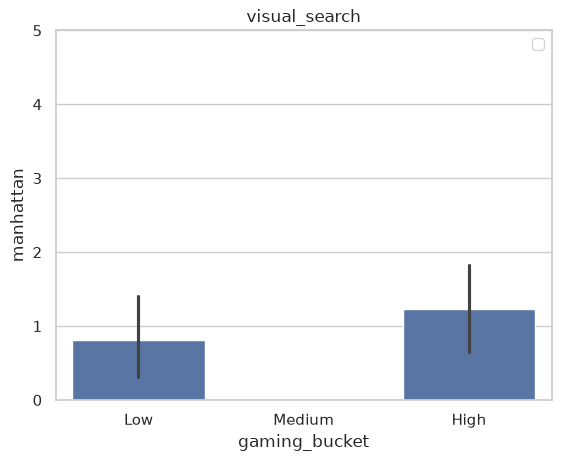

In [611]:
for condition in conditions:
    data= MEMORY_TEST_WITH_DEMOGRAPHICS[MEMORY_TEST_WITH_DEMOGRAPHICS['condition_demographics']==condition]
    plt.figure()
    sns.barplot(data=data, x="gaming_bucket", y="manhattan")
    plt.title(f"{condition}")
    plt.xticks(
        range(3),
        ["Low", "Medium", "High"],
    )
    plt.ylim(0,5)
    plt.legend(title="")
    plt.savefig(f"./plots/{FOLDER_NAME}/memory-test/memory_test_by_gaming_bucket_{condition}.png")

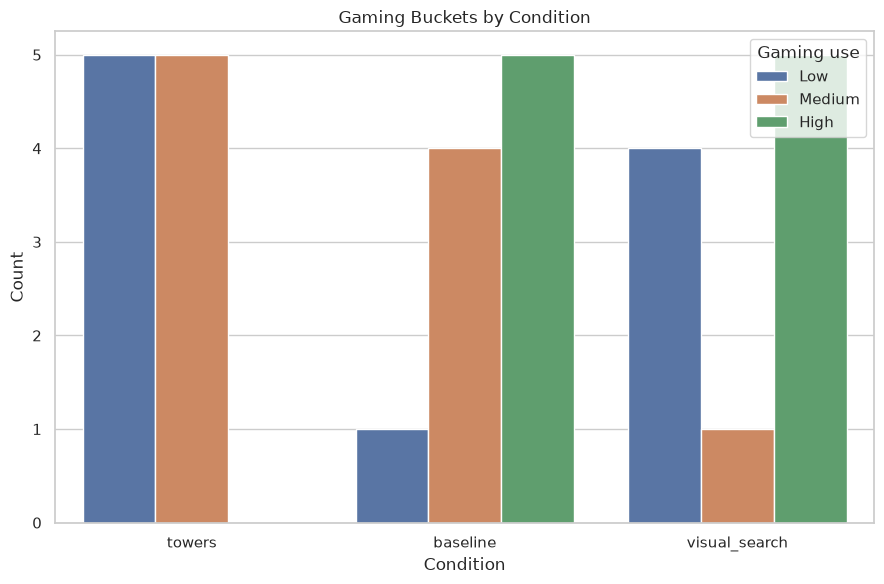

In [612]:
gaming_order = ["Low", "Medium", "High"]
condition_order = ["towers", "baseline", "visual_search"]

GAMING_BUCKET_COUNTS = MEMORY_TEST_WITH_DEMOGRAPHICS[['videoGameUsage', 'unique_id', 'condition_demographics']].drop_duplicates()
GAMING_BUCKET_COUNTS['gaming_bucket'] = GAMING_BUCKET_COUNTS['videoGameUsage'].apply(lambda x: _assignVideoGameUseBucket(x))

GAMING_BUCKET_COUNTS.columns 

plt.figure(figsize=(9, 6))
ax = sns.countplot(
    data=GAMING_BUCKET_COUNTS,
    x="condition_demographics",
    hue="gaming_bucket",
    order=condition_order,
    hue_order=gaming_order,
)

ax.set_xlabel("Condition")
ax.set_ylabel("Count")
ax.set_title("Gaming Buckets by Condition")
ax.legend(title="Gaming use")
plt.tight_layout()
plt.savefig(f"./plots/{FOLDER_NAME}/demographics/gaming_buckets.png")
plt.show()